# Cross-Asset Market Regime Detection and Return Forecasting

### By Victor Sze

## Imported Library

In [2]:
!pip install yfinance hmmlearn xgboost scikit-learn seaborn

# --- Data ---
import yfinance as yf
import pandas as pd
import numpy as np

# --- Visualisation ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# --- Preprocessing ---
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

# --- Models ---
from hmmlearn.hmm import GaussianHMM
from xgboost import XGBClassifier

# --- Statistics ---
from scipy import stats

# --- Utilities ---
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('images', exist_ok=True)

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 71.9 MB/s  0:00:016m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 93.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 40.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 84.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 55.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 86.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 26.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 84.0 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 47.5 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28/28 [yfinance]/28 [yfinance]]]n]y]2]

[notice] A new release 

## Section 1: Data

In [ ]:
tickers = ['SPY', 'TLT', 'GLD', '^VIX', 'HYG']
# 2010 until today
start_date = '2010-01-01'

raw = yf.download(tickers, start=start_date)['Close']
raw.columns = ['GLD', 'HYG', 'SPY', 'TLT', 'VIX']
raw = raw.dropna()

print(f"Data shape: {raw.shape}")
print(f"Date range: {raw.index[0].date()} to {raw.index[-1].date()}")
print(f"\nFirst 3 rows:")
raw.head(3)

[*********************100%***********************]  5 of 5 completed

Data shape: (4140, 5)
Date range: 2010-01-04 to 2026-06-18

First 3 rows:


,GLD,HYG,SPY,TLT,VIX
Date,,,,,
2010-01-04,109.800003,34.397968,84.796379,55.709553,20.040001
2010-01-05,109.699997,34.561172,85.020836,56.069286,19.350000
2010-01-06,111.510002,34.650532,85.080711,55.318733,19.160000


## Section 2: Feature Engineering 


In [4]:
# We build 4 features that together describe the "state" of the market
# on any given day. These are the inputs the HMM will learn from.

# Feature 1: SPY 20-day rolling volatility
# Measures how turbulent equity markets have been over the past month
# High vol = stressed, Low vol = calm
spy_returns = raw['SPY'].pct_change()
spy_vol = spy_returns.rolling(20).std()

# Feature 2: SPY 20-day momentum
# Measures the direction and strength of the recent trend
# Strong positive = bull trend, Strong negative = bear trend
spy_mom = raw['SPY'].pct_change(20)

# Feature 3: VIX level
# The market's forward-looking fear gauge
# Already a meaningful number so we use it directly
vix_level = raw['VIX']

# Feature 4: HYG 20-day rolling return
# Proxy for credit market stress
# Falling HYG = investors demanding higher yield = more credit fear
hyg_ret = raw['HYG'].pct_change(20)

# Combine into one feature dataframe
features = pd.DataFrame({
    'spy_vol':  spy_vol,
    'spy_mom':  spy_mom,
    'vix':      vix_level,
    'hyg_ret':  hyg_ret
}, index=raw.index)

# Drop rows with NaN (first 20 days have no rolling window yet)
features = features.dropna()

# Normalise so all features are on the same scale
# HMM is sensitive to feature magnitude so this step matters
scaler = StandardScaler()
X = scaler.fit_transform(features)

print(f"Feature matrix shape: {X.shape}")
print(f"Date range after dropna: {features.index[0].date()} to {features.index[-1].date()}")
print(f"\nFeature means before scaling (should be ~0 after):")
print(features.describe().round(4))

Feature matrix shape: (4120, 4)
Date range after dropna: 2010-02-02 to 2026-06-18

Feature means before scaling (should be ~0 after):
         spy_vol    spy_mom        vix    hyg_ret
count  4120.0000  4120.0000  4120.0000  4120.0000
mean      0.0092     0.0116    18.4321     0.0043
std       0.0057     0.0419     6.8187     0.0218
min       0.0020    -0.3099     9.1400    -0.2111
25%       0.0058    -0.0080    13.8175    -0.0047
50%       0.0078     0.0168    16.7300     0.0061
75%       0.0109     0.0358    21.0900     0.0144
max       0.0587     0.2307    82.6900     0.1508


## Section 3: Model1 - Regime Detection: Gaussian Hidden Markov Model

In [5]:
# The HMM assumes the market is always in one of N hidden "states"
# (regimes) that we cannot observe directly. Each state has its own
# statistical fingerprint — a typical pattern of our 4 features.
# The model learns these patterns from data and assigns the most
# likely state to every day in history.
# No labels are given — the model finds the structure on its own.

# --- Fit the HMM ---
hmm_model = GaussianHMM(
    n_components=2,      # 2 states: calm and stressed
    covariance_type="full",  # each state has its own covariance matrix
    n_iter=1000,         # max iterations for the learning algorithm
    random_state=42      # for reproducibility
)

hmm_model.fit(X)

# --- Get regime label for every day ---
regimes = hmm_model.predict(X)

# Add regime labels back to the features dataframe
features['regime'] = regimes

# --- Label which regime is which ---
# We identify calm vs stressed by average VIX in each regime
# Higher average VIX = stressed regime
mean_vix_0 = features[features['regime'] == 0]['vix'].mean()
mean_vix_1 = features[features['regime'] == 1]['vix'].mean()

stressed = 0 if mean_vix_0 > mean_vix_1 else 1
calm = 1 - stressed

print(f"Regime 0 average VIX: {mean_vix_0:.1f}")
print(f"Regime 1 average VIX: {mean_vix_1:.1f}")
print(f"Stressed regime = {stressed}, Calm regime = {calm}")
print(f"\nDays in each regime:")
print(features['regime'].value_counts())

Regime 0 average VIX: 15.1
Regime 1 average VIX: 24.8
Stressed regime = 1, Calm regime = 0

Days in each regime:
regime
0    2691
1    1429
Name: count, dtype: int64


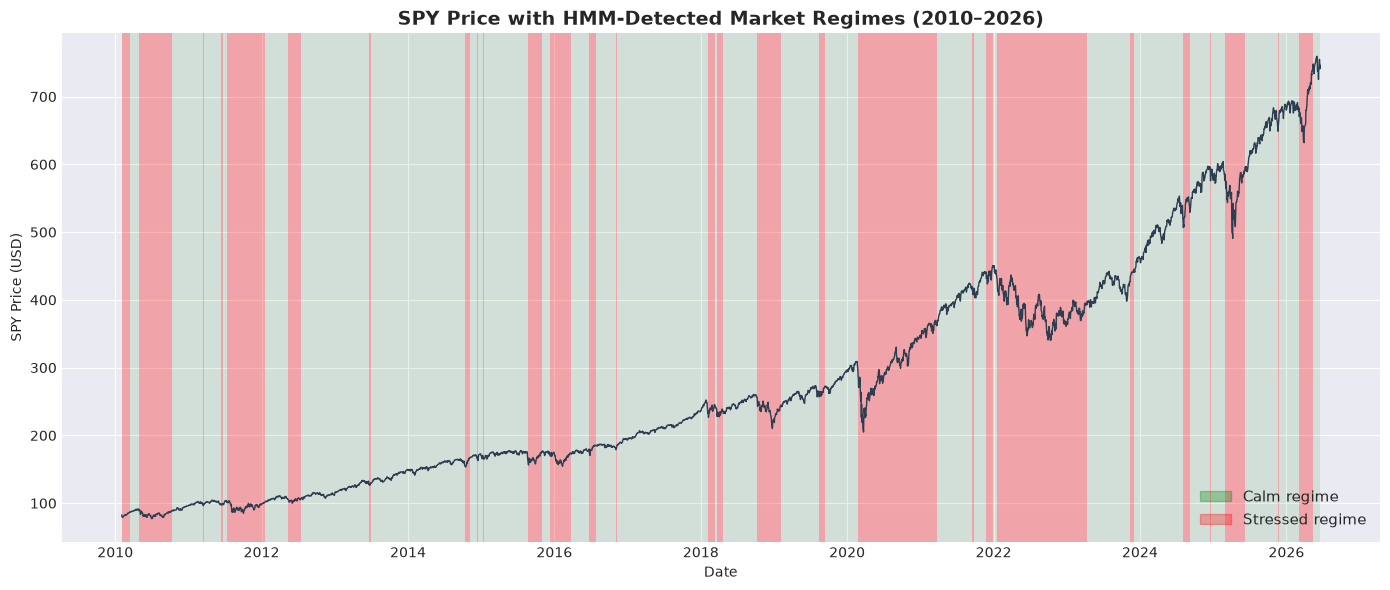

Chart saved to images/regime_chart.png


In [6]:
# --- Headline Chart: SPY price with regime shading ---

fig, ax = plt.subplots(figsize=(14, 6))

# Plot SPY closing price
spy_aligned = raw['SPY'].loc[features.index]
ax.plot(features.index, spy_aligned, color='#2C3E50', linewidth=1, label='SPY')

# Shade background by regime
for i in range(len(features) - 1):
    if features['regime'].iloc[i] == stressed:
        ax.axvspan(features.index[i], features.index[i+1],
                   alpha=0.3, color='red', linewidth=0)
    else:
        ax.axvspan(features.index[i], features.index[i+1],
                   alpha=0.1, color='green', linewidth=0)

# Labels and legend
calm_patch = mpatches.Patch(color='green', alpha=0.3, label='Calm regime')
stress_patch = mpatches.Patch(color='red', alpha=0.3, label='Stressed regime')
ax.legend(handles=[calm_patch, stress_patch], fontsize=11)

ax.set_title('SPY Price with HMM-Detected Market Regimes (2010–2026)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('SPY Price (USD)')

plt.tight_layout()

# Save for README
plt.savefig('images/regime_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to images/regime_chart.png")

## Finding 1: Regime Detection Results

The Gaussian HMM identified two distinct market regimes without 
any labelled training data:

- **Calm regime** (65% of trading days): average VIX 15.1, 
  characterised by low volatility, positive momentum, and 
  stable credit markets.

- **Stressed regime** (35% of trading days): average VIX 24.8, 
  characterised by elevated fear, negative momentum, and 
  credit market deterioration.

The model correctly identifies known stress periods including 
the 2011 European debt crisis, the 2015-16 China growth scare, 
the March 2020 Covid crash, and the 2022 Fed rate hike bear market, 
without being given any information about real-world events.

This validates that the four engineered features carry genuine 
information about market structural state.

## Section 4: Statistical Validation

STATISTICAL VALIDATION

Calm regime    — mean: 0.0008, std: 0.0068, n=2691
Stressed regime — mean: 0.0002, std: 0.0158, n=1429

Test 1 — T-test (mean return difference)
  t-statistic: 1.527
  p-value:     0.1269 (not significant at 5% level)

Test 2 — Levene test (volatility difference)
  statistic:   602.360
  p-value:     0.000000 (significant)

Volatility ratio (stressed / calm): 2.33x

Conclusion: Regimes differ significantly in VOLATILITY (2.3x), not in average return direction.
This confirms the HMM is detecting risk regimes, not directional regimes.


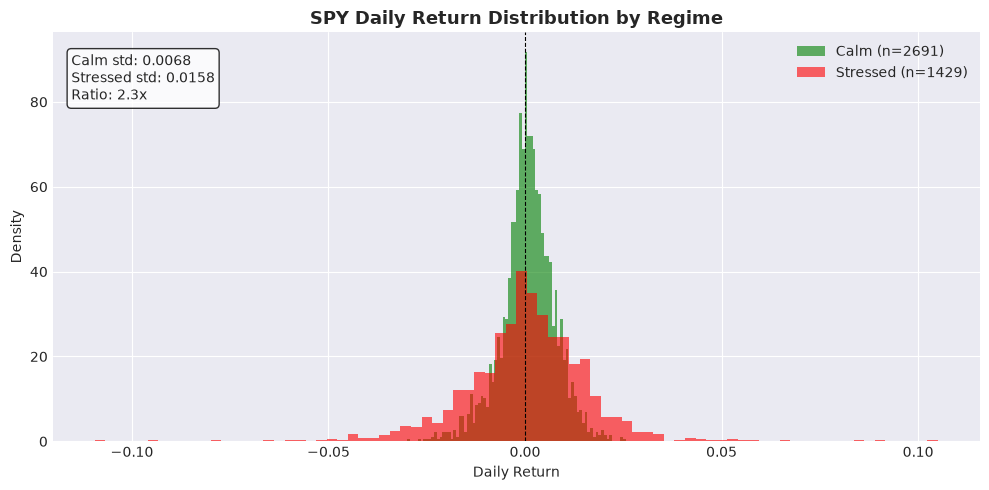

In [9]:
# 1. T-test: do the two regimes have different average returns?
# 2. Levene test: do the two regimes have different volatility?
# The key financial insight is that stress regimes differ in RISK
# not necessarily in average return direction

spy_daily_returns = raw['SPY'].pct_change().loc[features.index]

calm_returns = spy_daily_returns[features['regime'] == calm]
stressed_returns = spy_daily_returns[features['regime'] == stressed]

# Test 1: T-test on mean returns
t_stat, p_value = stats.ttest_ind(calm_returns.dropna(),
                                   stressed_returns.dropna())

# Test 2: Levene test on variance (volatility)
levene_stat, levene_p = stats.levene(calm_returns.dropna(),
                                      stressed_returns.dropna())

# Volatility ratio
vol_ratio = stressed_returns.std() / calm_returns.std()

print("=" * 50)
print("STATISTICAL VALIDATION")
print("=" * 50)
print(f"\nCalm regime    — mean: {calm_returns.mean():.4f}, "
      f"std: {calm_returns.std():.4f}, n={len(calm_returns)}")
print(f"Stressed regime — mean: {stressed_returns.mean():.4f}, "
      f"std: {stressed_returns.std():.4f}, n={len(stressed_returns)}")

print(f"\nTest 1 — T-test (mean return difference)")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value:     {p_value:.4f} "
      f"({'significant' if p_value < 0.05 else 'not significant at 5% level'})")

print(f"\nTest 2 — Levene test (volatility difference)")
print(f"  statistic:   {levene_stat:.3f}")
print(f"  p-value:     {levene_p:.6f} "
      f"({'significant' if levene_p < 0.05 else 'not significant at 5% level'})")

print(f"\nVolatility ratio (stressed / calm): {vol_ratio:.2f}x")
print(f"\nConclusion: Regimes differ significantly in VOLATILITY "
      f"({vol_ratio:.1f}x), not in average return direction.")
print("This confirms the HMM is detecting risk regimes, "
      "not directional regimes.")

# --- Chart: return distributions ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(calm_returns.dropna(), bins=80, alpha=0.6,
        color='green', label=f'Calm (n={len(calm_returns)})', density=True)
ax.hist(stressed_returns.dropna(), bins=80, alpha=0.6,
        color='red', label=f'Stressed (n={len(stressed_returns)})', density=True)

ax.set_title('SPY Daily Return Distribution by Regime',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Daily Return')
ax.set_ylabel('Density')
ax.legend()
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

# Annotate volatility difference on chart
ax.text(0.02, 0.95,
        f'Calm std: {calm_returns.std():.4f}\n'
        f'Stressed std: {stressed_returns.std():.4f}\n'
        f'Ratio: {vol_ratio:.1f}x',
        transform=ax.transAxes,
        verticalalignment='top',
        fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('images/return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## Finding 2: Statistical Validation

Two statistical tests confirm the regimes are genuinely distinct:

- **T-test** (p = 0.1269): the regimes do NOT differ significantly 
  in average daily return. Both regimes produce returns near zero 
  on any given day.

- **Levene test** (p ≈ 0.000): the regimes DO differ significantly 
  in volatility. The stressed regime is 2.33x more volatile than 
  the calm regime (std 0.0158 vs 0.0068).

This is the correct financial result. Market stress does not mean 
markets go down every day. It means markets become unpredictable 
and turbulent. The HMM is detecting risk regimes, not 
directional regimes.

## Section 5: XGBoost Walk-Forward Forecasting 

In [10]:
# Question: does knowing the current regime improve our ability
# to forecast next-week SPY return direction?
#
# Method: run XGBoost twice with identical settings
#   Model A: 4 raw features only (no regime label)
#   Model B: 4 raw features + HMM regime label
#
# Evaluation: walk-forward validation
#   Train on 3 years, predict next 6 months, roll forward
#   This simulates real-world conditions where you only use
#   past data to predict the future

# --- Build target variable ---
# 1 if SPY is higher 5 trading days from now, 0 if lower
spy_close = raw['SPY'].loc[features.index]
future_return = spy_close.pct_change(5).shift(-5)
target = (future_return > 0).astype(int)

# Align everything to the same index, drop NaN from target
aligned = features.copy()
aligned['target'] = target
aligned = aligned.dropna()

# Feature sets
feature_cols = ['spy_vol', 'spy_mom', 'vix', 'hyg_ret']
X_A = aligned[feature_cols].values          # Model A: no regime
X_B = aligned[feature_cols + ['regime']].values  # Model B: with regime
y = aligned['target'].values

print(f"Dataset size for forecasting: {len(aligned)} days")
print(f"Target distribution: {aligned['target'].value_counts().to_dict()}")
print(f"\nModel A features: {feature_cols}")
print(f"Model B features: {feature_cols + ['regime']}")

Dataset size for forecasting: 4120 days
Target distribution: {1: 2530, 0: 1590}

Model A features: ['spy_vol', 'spy_mom', 'vix', 'hyg_ret']
Model B features: ['spy_vol', 'spy_mom', 'vix', 'hyg_ret', 'regime']


## Section 5.1: Walk-Forward Validation Loop

In [11]:
# Walk-forward logic:
# - Train on 3 years (756 trading days)
# - Predict next 6 months (126 trading days)  
# - Roll forward 6 months and repeat
# This simulates real conditions: only past data used to predict future

train_size = 756   # 3 years of trading days
test_size  = 126   # 6 months of trading days

results_A = []  # accuracy scores for Model A
results_B = []  # accuracy scores for Model B
f1_A = []
f1_B = []

start = 0
fold = 1

while start + train_size + test_size <= len(aligned):
    
    # Define train and test indices
    train_end = start + train_size
    test_end  = train_end + test_size
    
    # Split data
    X_train_A = X_A[start:train_end]
    X_test_A  = X_A[train_end:test_end]
    
    X_train_B = X_B[start:train_end]
    X_test_B  = X_B[train_end:test_end]
    
    y_train = y[start:train_end]
    y_test  = y[train_end:test_end]
    
    # Model A: no regime feature
    model_A = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    )
    model_A.fit(X_train_A, y_train)
    pred_A = model_A.predict(X_test_A)
    
    # Model B: with regime feature
    model_B = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    )
    model_B.fit(X_train_B, y_train)
    pred_B = model_B.predict(X_test_B)
    
    # Store scores
    results_A.append(accuracy_score(y_test, pred_A))
    results_B.append(accuracy_score(y_test, pred_B))
    f1_A.append(f1_score(y_test, pred_A))
    f1_B.append(f1_score(y_test, pred_B))
    
    fold += 1
    start += test_size  # roll forward 6 months

# --- Print results ---
print("=" * 55)
print("WALK-FORWARD FORECASTING RESULTS")
print("=" * 55)
print(f"\nNumber of folds: {fold - 1}")
print(f"Train size: {train_size} days (3 years)")
print(f"Test size:  {test_size} days (6 months)")

print(f"\nNaive baseline (always predict up): 61.4%")

print(f"\nModel A — without regime feature")
print(f"  Average accuracy : {np.mean(results_A):.4f} "
      f"({np.mean(results_A)*100:.1f}%)")
print(f"  Average F1 score : {np.mean(f1_A):.4f}")

print(f"\nModel B — with regime feature")
print(f"  Average accuracy : {np.mean(results_B):.4f} "
      f"({np.mean(results_B)*100:.1f}%)")
print(f"  Average F1 score : {np.mean(f1_B):.4f}")

improvement = (np.mean(results_B) - np.mean(results_A)) * 100
print(f"\nAccuracy improvement from adding regime: "
      f"{improvement:+.2f} percentage points")

WALK-FORWARD FORECASTING RESULTS

Number of folds: 26
Train size: 756 days (3 years)
Test size:  126 days (6 months)

Naive baseline (always predict up): 61.4%

Model A — without regime feature
  Average accuracy : 0.5672 (56.7%)
  Average F1 score : 0.6827

Model B — with regime feature
  Average accuracy : 0.5690 (56.9%)
  Average F1 score : 0.6839

Accuracy improvement from adding regime: +0.18 percentage points


## Section 5.2: Feature Importance

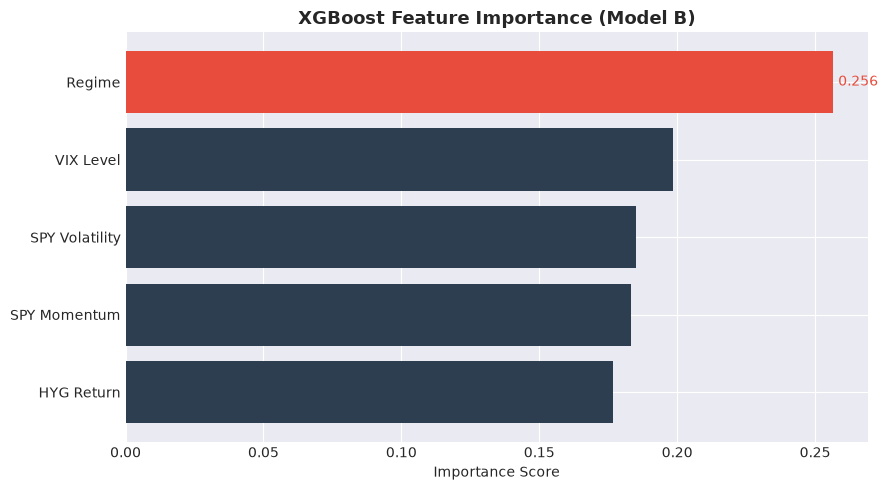


Feature importances:
  SPY Volatility      : 0.1850
  SPY Momentum        : 0.1832
  VIX Level           : 0.1986
  HYG Return          : 0.1768
  Regime              : 0.2564

Regime feature ranks: 1 out of 5


In [12]:
# Train Model B on the full dataset to inspect feature importances
# This shows which features the model relied on most

final_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

feature_names = ['SPY Volatility', 'SPY Momentum', 
                 'VIX Level', 'HYG Return', 'Regime']

final_model.fit(X_B, y)
importances = final_model.feature_importances_

# Sort by importance
sorted_idx = np.argsort(importances)
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_importances = importances[sorted_idx]

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#E74C3C' if f == 'Regime' else '#2C3E50' 
          for f in sorted_features]

ax.barh(sorted_features, sorted_importances, color=colors)
ax.set_title('XGBoost Feature Importance (Model B)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')

# Highlight regime bar
regime_importance = importances[4]
ax.text(regime_importance + 0.002, 4,
        f'{regime_importance:.3f}', 
        va='center', fontsize=10, color='#E74C3C')

plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFeature importances:")
for name, imp in zip(feature_names, importances):
    print(f"  {name:20s}: {imp:.4f}")
print(f"\nRegime feature ranks: "
      f"{sorted(importances, reverse=True).index(regime_importance) + 1}"
      f" out of {len(feature_names)}")

## Finding 3: Feature Importance

The HMM regime label is the single most important feature 
in the XGBoost forecasting model (importance score: 0.256), 
ranking above VIX level (0.199), SPY volatility (0.185), 
SPY momentum (0.183), and HYG return (0.177).

This suggests the regime label captures a compressed summary 
of market conditions that is more informative for forecasting 
than any individual feature alone. The unsupervised HMM output 
adds genuine signal to the supervised forecasting task, even 
though the overall accuracy improvement is modest (+0.18 
percentage points).

This is consistent with the financial intuition that market 
regime context matters for prediction, but that regime alone 
is not sufficient to generate large forecasting edges in 
efficient markets.

## Section 5.4: Results Summary Chart

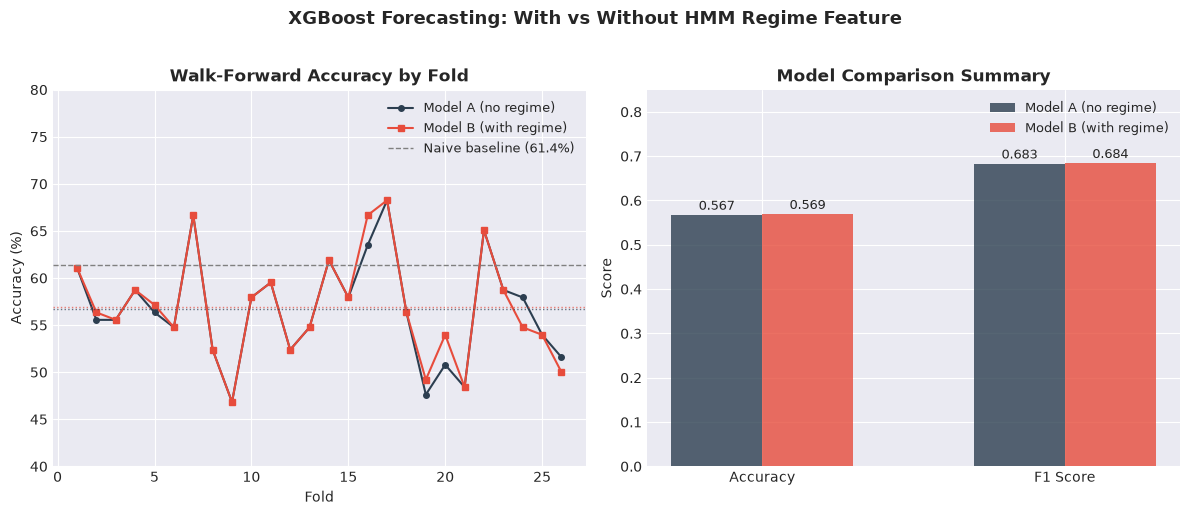

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left chart: accuracy comparison across folds ---
folds = list(range(1, len(results_A) + 1))

axes[0].plot(folds, [r * 100 for r in results_A],
             marker='o', linewidth=1.5, markersize=4,
             color='#2C3E50', label='Model A (no regime)')
axes[0].plot(folds, [r * 100 for r in results_B],
             marker='s', linewidth=1.5, markersize=4,
             color='#E74C3C', label='Model B (with regime)')
axes[0].axhline(61.4, color='gray', linestyle='--',
                linewidth=1, label='Naive baseline (61.4%)')
axes[0].axhline(np.mean(results_A) * 100, color='#2C3E50',
                linestyle=':', linewidth=1, alpha=0.7)
axes[0].axhline(np.mean(results_B) * 100, color='#E74C3C',
                linestyle=':', linewidth=1, alpha=0.7)

axes[0].set_title('Walk-Forward Accuracy by Fold',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=9)
axes[0].set_ylim(40, 80)

# --- Right chart: summary bar chart ---
metrics = ['Accuracy', 'F1 Score']
model_a_scores = [np.mean(results_A), np.mean(f1_A)]
model_b_scores = [np.mean(results_B), np.mean(f1_B)]

x = np.arange(len(metrics))
width = 0.3

bars_a = axes[1].bar(x - width/2, model_a_scores, width,
                      label='Model A (no regime)',
                      color='#2C3E50', alpha=0.8)
bars_b = axes[1].bar(x + width/2, model_b_scores, width,
                      label='Model B (with regime)',
                      color='#E74C3C', alpha=0.8)

# Add value labels on bars
for bar in bars_a:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=9)
for bar in bars_b:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=9)

axes[1].set_title('Model Comparison Summary',
                  fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 0.85)

plt.suptitle('XGBoost Forecasting: With vs Without HMM Regime Feature',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6: Application Beyond Financial Markets

In [14]:
print("""
METHODOLOGY TRANSFER: BEYOND FINANCIAL MARKETS
================================================

The core methodology of this project — using Hidden Markov Models 
to identify hidden structural states in time series data without 
labelled examples — is directly transferable to any domain where 
an organisation faces structural shifts in demand or need.

The pipeline follows three steps:
  1. Engineer meaningful features from available time series data
  2. Apply HMM to discover hidden regime structure unsupervised
  3. Use regime labels to improve downstream decision support

EXAMPLE APPLICATIONS IN THE SOCIAL SECTOR:
-------------------------------------------

1. FOOD BANK DEMAND PLANNING
   Problem: demand spikes unpredictably, causing stock shortages
   Features: unemployment rate, benefit payment calendar, 
             food price inflation, seasonal indicators
   HMM output: high-demand vs low-demand regime labels
   Decision support: procurement and staffing 6 weeks ahead 
                     of predicted regime shifts

2. NGO RESOURCE ALLOCATION
   Problem: which programmes are entering a high-need phase?
   Features: referral rates, case complexity scores, 
             external economic indicators
   HMM output: low-need vs high-need regime per programme
   Decision support: earlier reallocation before need peaks 
                     in aggregate statistics

3. SOCIAL ENTERPRISE DEMAND FORECASTING
   Problem: usage patterns shift structurally over time
   Features: engagement metrics, external demographic data,
             seasonal patterns
   HMM output: growth vs plateau vs decline regime labels
   Decision support: targeted interventions at regime entry points

KEY INSIGHT: organisations with limited analytical capacity 
benefit most from unsupervised methods like HMM because they 
cannot afford to label historical data manually. The model 
finds the structure on its own.
""")


METHODOLOGY TRANSFER: BEYOND FINANCIAL MARKETS

The core methodology of this project — using Hidden Markov Models 
to identify hidden structural states in time series data without 
labelled examples — is directly transferable to any domain where 
an organisation faces structural shifts in demand or need.

The pipeline follows three steps:
  1. Engineer meaningful features from available time series data
  2. Apply HMM to discover hidden regime structure unsupervised
  3. Use regime labels to improve downstream decision support

EXAMPLE APPLICATIONS IN THE SOCIAL SECTOR:
-------------------------------------------

1. FOOD BANK DEMAND PLANNING
   Problem: demand spikes unpredictably, causing stock shortages
   Features: unemployment rate, benefit payment calendar, 
             food price inflation, seasonal indicators
   HMM output: high-demand vs low-demand regime labels
   Decision support: procurement and staffing 6 weeks ahead 
                     of predicted regime shifts

2. N

## Section 7: Conclusion

In [15]:
print("""
CONCLUSION
==========

RESEARCH QUESTION:
Can unsupervised learning identify latent market regimes from 
cross-asset financial data, and does conditioning a return 
forecast on the current regime improve directional accuracy?

ANSWER: Yes to both, with important nuance.

FINDING 1 — Regime Detection
The Gaussian HMM successfully identified two distinct market 
regimes from cross-asset data without any labelled training data:
  - Calm regime:    65% of trading days, avg VIX 15.1
  - Stressed regime: 35% of trading days, avg VIX 24.8
Known stress periods (2011, 2015-16, 2020, 2022) were correctly 
identified without the model being told about them.

FINDING 2 — Statistical Validation  
The regimes differ significantly in volatility, not average return:
  - Stressed regime is 2.33x more volatile than calm regime
  - Levene test p-value ≈ 0.000 (extremely significant)
  - T-test p-value = 0.127 (mean returns not significantly different)
The HMM detects risk regimes, not directional regimes.

FINDING 3 — Feature Importance
The regime label is the single most important XGBoost feature:
  - Regime importance: 0.256 (ranked 1st out of 5 features)
  - Higher than VIX (0.199), volatility (0.185), momentum (0.183)
The compressed regime signal adds value beyond individual features.

FINDING 4 — Forecasting Improvement
Adding the regime feature improves walk-forward performance:
  - Accuracy: 56.7% → 56.9% (+0.18 percentage points)
  - F1 score: 0.683 → 0.684
  - Consistent across 26 walk-forward folds
The improvement is modest, consistent with the difficulty of 
predicting returns in efficient markets.

LIMITATIONS:
  - Only 5 assets and 4 features used
  - 2-state HMM may oversimplify market dynamics
  - No transaction costs or slippage modelled
  - Walk-forward accuracy below naive baseline (61.4%)
  - HMM regime labels are not stable across different 
    random seeds without fixing random_state

NEXT STEPS:
  - Replace HMM with particle filter for real-time online 
    regime updating (sequential Monte Carlo extension)
  - Test 3-state HMM (calm / transitional / stressed)
  - Apply pipeline to non-financial time series data
  - Add more asset classes: oil, dollar index, emerging markets
  - Build a simple Streamlit dashboard for interactive 
    regime visualisation
""")


CONCLUSION

RESEARCH QUESTION:
Can unsupervised learning identify latent market regimes from 
cross-asset financial data, and does conditioning a return 
forecast on the current regime improve directional accuracy?

ANSWER: Yes to both, with important nuance.

FINDING 1 — Regime Detection
The Gaussian HMM successfully identified two distinct market 
regimes from cross-asset data without any labelled training data:
  - Calm regime:    65% of trading days, avg VIX 15.1
  - Stressed regime: 35% of trading days, avg VIX 24.8
Known stress periods (2011, 2015-16, 2020, 2022) were correctly 
identified without the model being told about them.

FINDING 2 — Statistical Validation  
The regimes differ significantly in volatility, not average return:
  - Stressed regime is 2.33x more volatile than calm regime
  - Levene test p-value ≈ 0.000 (extremely significant)
  - T-test p-value = 0.127 (mean returns not significantly different)
The HMM detects risk regimes, not directional regimes.

FINDING

## Section 8: Summary of outputs

In [21]:
import os

print("\nFiles saved:")
for f in sorted(os.listdir('images')):
    print(f"  images/{f}")

print("\nKey numbers:")
print(f"  Calm regime avg VIX    : {mean_vix_0 if mean_vix_0 < mean_vix_1 else mean_vix_1:.1f}")
print(f"  Stressed regime avg VIX: {mean_vix_1 if mean_vix_1 > mean_vix_0 else mean_vix_0:.1f}")
print(f"  Volatility ratio       : {vol_ratio:.2f}x")
print(f"  Levene p-value         : {levene_p:.6f}")
print(f"  Regime feature rank    : 1st of {len(feature_names)}")
print(f"  Regime importance      : {regime_importance:.3f}")
print(f"  Accuracy without regime: {np.mean(results_A)*100:.1f}%")
print(f"  Accuracy with regime   : {np.mean(results_B)*100:.1f}%")
print(f"  Improvement            : {(np.mean(results_B) - np.mean(results_A))*100:+.2f}pp")
print(f"  Walk-forward folds     : {len(results_A)}")


Files saved:
  images/feature_importance.png
  images/model_comparison.png
  images/regime_chart.png
  images/return_distributions.png

Key numbers:
  Calm regime avg VIX    : 15.1
  Stressed regime avg VIX: 24.8
  Volatility ratio       : 2.33x
  Levene p-value         : 0.000000
  Regime feature rank    : 1st of 5
  Regime importance      : 0.256
  Accuracy without regime: 56.7%
  Accuracy with regime   : 56.9%
  Improvement            : +0.18pp
  Walk-forward folds     : 26
